# Project Title Saudi Arabia Real Estate (AQAR)
---

## Introduction 
__Introduction to the topic__ 

  There are several variations among properties within the real estate market of Saudi Arabia that involve price, size, location, and features. The knowledge of these variations can provide insight into the patterns within property listing.

This study applies Exploratory Data Analysis (EDA) on the AQAR dataset that consists of 3,718 listings and 24 columns from four cities in Saudi Arabia: Riyadh, Jeddah, Dammam, and Khobar.

This analysis involves the analysis of the variation in prices between cities and districts as well as the relationship between property characteristics and prices. These property characteristics include size, bedroom, age, swimming pool, and frontyard.

---

## Problem Statement

The rental prices of the houses in Riyadh, Jeddah, Dammam, and Khobar differ widely even for those with the same specifications. The reason being that the properties differ in terms of location, features, and rental periods.

Moreover, duplication of data and presence of extreme values in the data may compromise the reliability of the data analysis results.

## Objectives:
__Questions that will guide the analysis to solve the problem__
1. Discuss how the listing is distributed over the four cities.
2. Analyse the distribution of the annual rental price estimate.
3. Compare median annual rental price estimates of the cities.
4. Compare annual prices per square meter of the cities.
5. Price Differences based on Location.
6. Analysis of the property size in relation to the price.
7. Price difference based on the number of bedrooms.
8. Age of the property in relation to the price.
9. Price differences based on whether there is a pool.
10. Citywise differences in price for the pool availability.
11. Frontyard Availability and Rental Price

---

### Analysis: 
__Answering the objectives through data analysis__



In [1]:

import pandas as pd
import matplotlib.pyplot as plt

df_analysis = pd.read_csv("SA_Aqar_cleaned.csv")

df_analysis.head()


,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,frontyard,basement,duplex,stairs,elevator,fireplace,price,details,rental_type,annual_price
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...,Unknown,80000
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...,Unknown,60000
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...,Unknown,60000
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...,Unknown,55000
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...,Unknown,70000


**Objective 1 — Distribution of listings by city**

In [2]:
df_analysis.groupby("city").size()

city
الخبر     976
الدمام    893
الرياض    960
جدة       886
dtype: int64

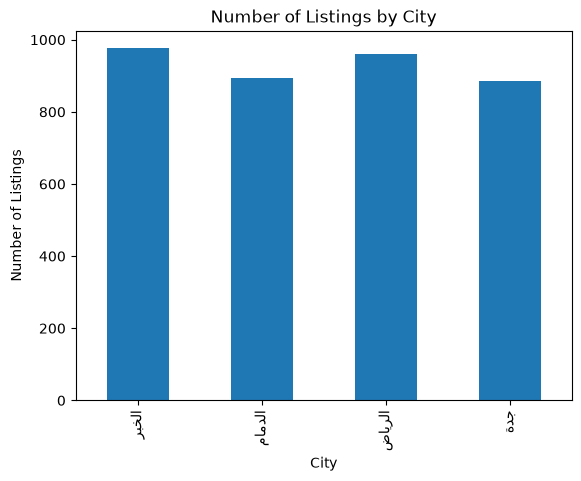

In [3]:
df_analysis.groupby("city").size().plot(kind="bar", title="Number of Listings by City", xlabel="City", ylabel="Number of Listings")

plt.show()

**Objective 2 — Overall price distribution**

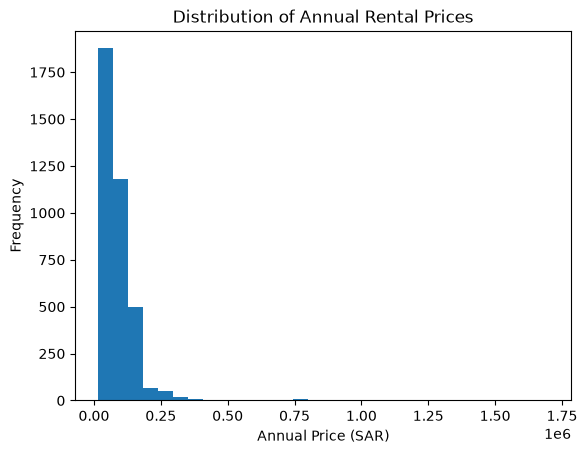

In [4]:
df_analysis["annual_price"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Annual Rental Prices",
    xlabel="Annual Price (SAR)"
)

plt.show()

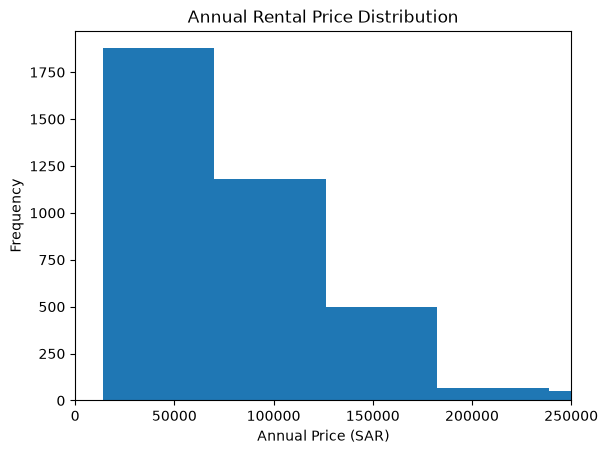

In [5]:
ax = df_analysis["annual_price"].plot(
    kind="hist",
    bins=30,
    title="Annual Rental Price Distribution",
    xlabel="Annual Price (SAR)"
)

ax.set_xlim(0, 250000)

plt.show()

**Objective 3 — Median estimated annual price by city**

In [6]:
df_analysis.groupby("city")["annual_price"].median()

city
الخبر     75000.0
الدمام    60000.0
الرياض    80000.0
جدة       95000.0
Name: annual_price, dtype: float64

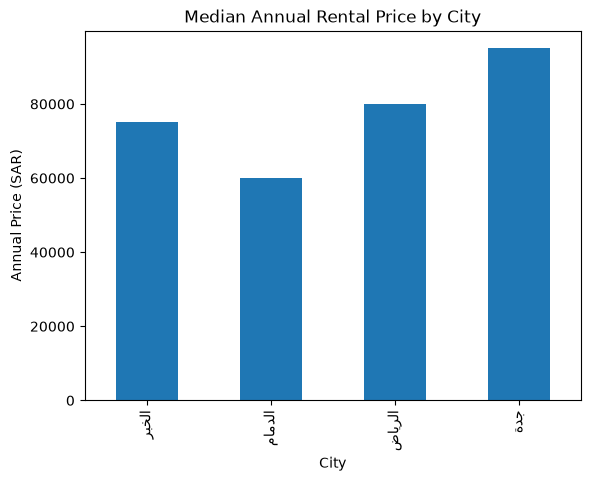

In [7]:
df_analysis.groupby("city")["annual_price"].median().plot(
    kind="bar",
    title="Median Annual Rental Price by City",
    xlabel="City",
    ylabel="Annual Price (SAR)"
)
plt.savefig("slide6_city_price.png", dpi=300, bbox_inches="tight")


plt.show()

**Objective 4 — Price per square metre by city**

In [8]:
df_analysis["price_per_m2"] = (
    df_analysis["annual_price"] / df_analysis["size"]
)

In [9]:
df_analysis.groupby("city")["price_per_m2"].median()

city
الخبر     200.000000
الدمام    157.894737
الرياض    224.679487
جدة       272.581585
Name: price_per_m2, dtype: float64

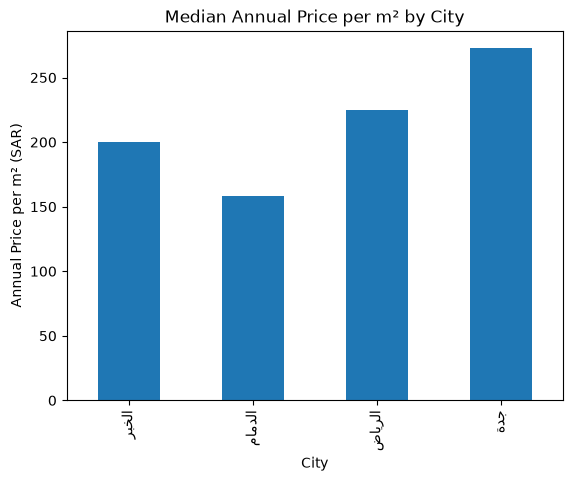

In [10]:
df_analysis.groupby("city")["price_per_m2"].median().plot(
    kind="bar",
    title="Median Annual Price per m² by City",
    xlabel="City",
    ylabel="Annual Price per m² (SAR)")
plt.savefig("slide6_price_per_m2.png", dpi=300, bbox_inches="tight")

plt.show()

**Objective 5 — Price Differences by District.** 

In [11]:
jeddah = df_analysis[df_analysis["city"] == "جدة"].copy()
jeddah["district"].value_counts().head(15)

district
حي الروضة           103
حي المحمدية         102
حي الشاطئ            98
حي البساتين          83
حي الزمرد            80
حي الياقوت           78
حي طيبة              71
حي الزهراء           49
حي بريمان            29
حي النعيم            23
حي ابحر الشمالية     15
حي النهضة            15
حي الخالدية          14
حي الصالحية          12
حي الحمدانية         11
Name: count, dtype: int64

In [12]:

jeddah_districts = jeddah.groupby("district")["annual_price"].agg(
    ["count", "median"]
).query("count >= 5").sort_values(
    "median", ascending=False
).head(10)

jeddah_districts


,count,median
district,,
حي الزهراء,49,160000.0
حي الخالدية,14,150000.0
حي الشاطئ,98,150000.0
حي الحمراء,7,120000.0
حي البساتين,83,110000.0
حي الصفا,7,100000.0
حي المحمدية,102,100000.0
حي النعيم,23,100000.0
حي الربوة,5,100000.0


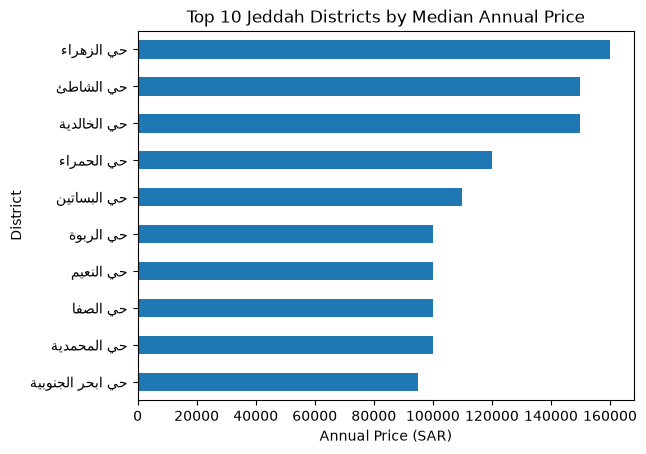

In [13]:
jeddah_districts["median"].sort_values().plot(
    kind="barh",
    title="Top 10 Jeddah Districts by Median Annual Price",
    xlabel="Annual Price (SAR)",
    ylabel="District"
)
plt.savefig("slide7 jeddah_districts.png", dpi=300, bbox_inches="tight")


plt.show()


In [14]:
riyadh = df_analysis[df_analysis["city"] == "الرياض"].copy()
riyadh["district"].value_counts().head(15)


district
حي العارض        137
حي الرمال        119
حي الملقا         39
حي طويق           38
حي النرجس         35
حي المونسية       34
حي العليا         31
حي القادسية       30
حي ظهرة لبن       28
حي السليمانية     24
حي الياسمين       22
حي الصحافة        21
حي العقيق         15
حي الروضة         13
حي القيروان       13
Name: count, dtype: int64

In [15]:

riyadh_districts = riyadh.groupby("district")["annual_price"].agg(
    ["count", "median"]
).query("count >= 5").sort_values(
    "median", ascending=False
).head(10)

riyadh_districts


,count,median
district,,
حي حطين,10,265000.0
حي الوادي,5,220000.0
حي الخزامى,6,150000.0
حي القدس,5,150000.0
حي العقيق,15,150000.0
حي الرحمانية,7,145000.0
حي الرائد,8,142500.0
حي التعاون,8,130000.0
حي الملقا,39,130000.0


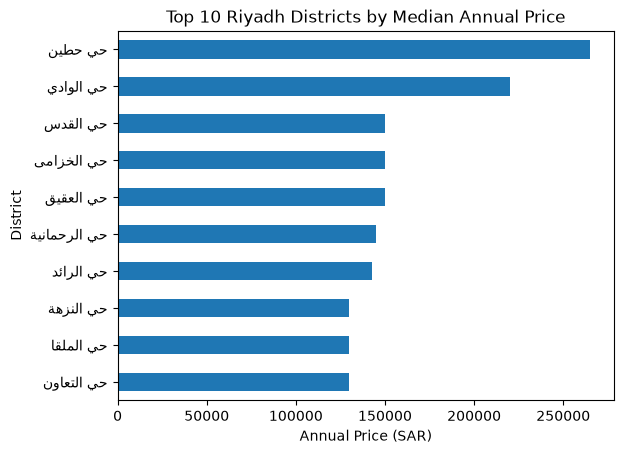

In [16]:

riyadh_districts["median"].sort_values().plot(
    kind="barh",
    title="Top 10 Riyadh Districts by Median Annual Price",
    xlabel="Annual Price (SAR)",
    ylabel="District"
)
plt.savefig("slide7 riyadh_districts.png", dpi=300, bbox_inches="tight")

plt.show()


In [17]:

dammam = df_analysis[df_analysis["city"] == "الدمام"].copy()

dammam["district"].value_counts().head(15)


district
حي ضاحية الملك فهد             172
حي المنار                       98
حي الشعلة                       69
حي طيبة                         53
حي الشاطئ الغربي                53
حي الحمراء                      49
حي بدر                          48
حي الخالدية الشمالية            47
حي المدينة الصناعية الثانية     47
حي السيف                        46
حي الفرسان                      46
حي الاثير                       46
حي المنتزه                      46
حي الجوهرة                      46
حي الندى                         6
Name: count, dtype: int64

In [18]:

dammam_districts = dammam.groupby("district")["annual_price"].agg(
    ["count", "median"]
).query("count >= 5").sort_values(
    "median", ascending=False
).head(10)

dammam_districts


,count,median
district,,
حي المنتزه,46,140000.0
حي الحمراء,49,85000.0
حي السيف,46,75000.0
حي الندى,6,75000.0
حي الخالدية الشمالية,47,70000.0
حي الشعلة,69,70000.0
حي المدينة الصناعية الثانية,47,65000.0
حي الاثير,46,60000.0
حي الشاطئ الغربي,53,60000.0


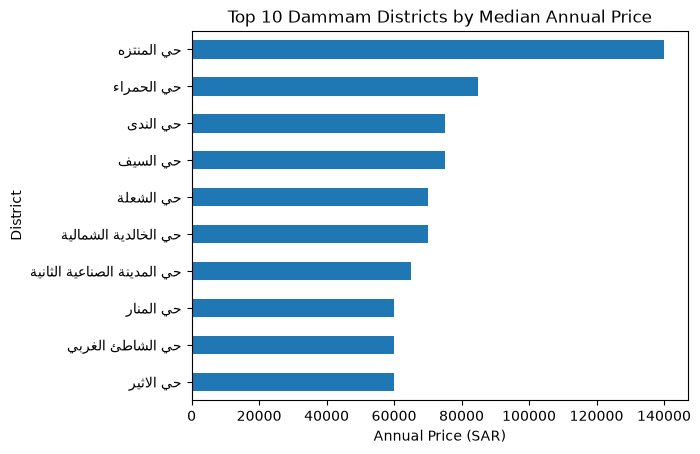

In [19]:

dammam_districts["median"].sort_values().plot(
    kind="barh",
    title="Top 10 Dammam Districts by Median Annual Price",
    xlabel="Annual Price (SAR)",
    ylabel="District"
)
plt.savefig("slide7 dammam_districts.png", dpi=300, bbox_inches="tight")

plt.show()


In [20]:

khobar = df_analysis[df_analysis["city"] == "الخبر"].copy()

khobar["district"].value_counts().head(15)


district
حي الصواري             149
حي التحلية             149
حي اللؤلؤ              148
حي الحزام الاخضر        96
حي الكورنيش             96
حي الراكة الجنوبية      52
حي البحيرة              51
حي الامواج              51
حي مدينة العمال         50
حي المدينة الرياضية     50
حي العليا               49
حي العقيق                7
حي الخزامى               4
حي قرطبة                 4
حي الشراع                4
Name: count, dtype: int64

In [21]:
khobar_districts = khobar.groupby("district")["annual_price"].agg(
    ["count", "median"]
).query("count >= 5").sort_values(
    "median", ascending=False
).head(10)

khobar_districts


,count,median
district,,
حي الحزام الاخضر,96,160000.0
حي الكورنيش,96,120000.0
حي الراكة الجنوبية,52,85000.0
حي البحيرة,51,80000.0
حي التحلية,149,80000.0
حي مدينة العمال,50,65000.0
حي العليا,49,65000.0
حي الامواج,51,60000.0
حي الصواري,149,55000.0


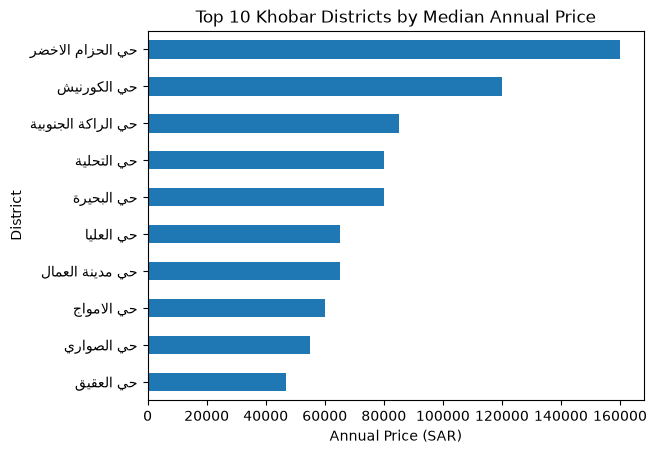

In [22]:

khobar_districts["median"].sort_values().plot(
    kind="barh",
    title="Top 10 Khobar Districts by Median Annual Price",
    xlabel="Annual Price (SAR)",
    ylabel="District"
)
plt.savefig("slide7 khobar_districts.png", dpi=300, bbox_inches="tight")

plt.show()


**Objective 6 — Size vs estimated annual price.** 

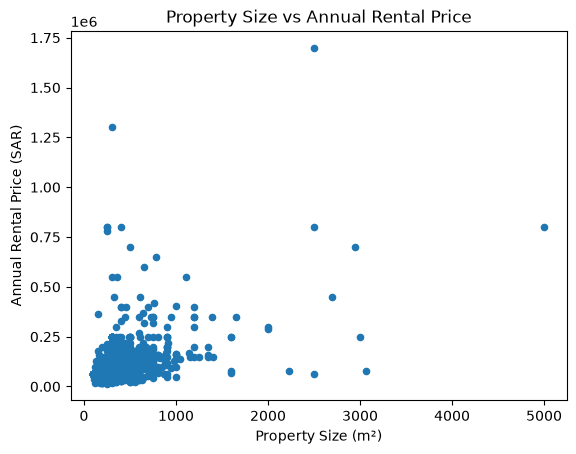

In [23]:
df_analysis.plot(
    kind="scatter",
    x="size",
    y="annual_price",
    title="Property Size vs Annual Rental Price",
    xlabel="Property Size (m²)",
    ylabel="Annual Rental Price (SAR)")
plt.savefig("slide8_size.png", dpi=300, bbox_inches="tight")


plt.show()

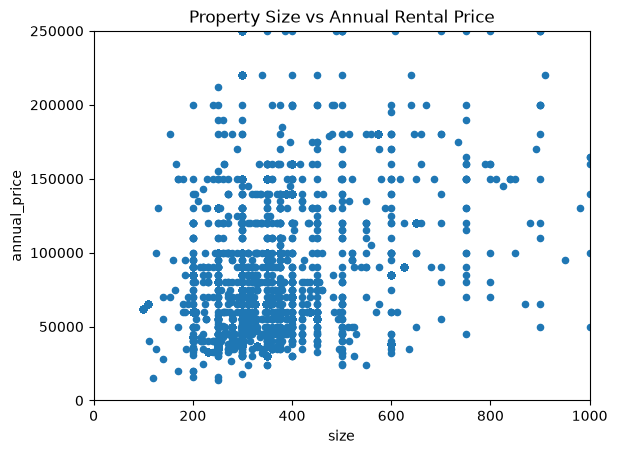

In [24]:
ax = df_analysis.plot(
    kind="scatter",
    x="size",
    y="annual_price",
    title="Property Size vs Annual Rental Price"
)

ax.set_xlim(0, 1000)
ax.set_ylim(0, 250000)

plt.show()

In [25]:
df_analysis["size"].corr(df_analysis["annual_price"])
#Moderate Positive Correlation

np.float64(0.4227052958335876)

**Objective 7 — Bedrooms vs estimated annual price**

In [26]:
df_analysis.groupby("bedrooms")["annual_price"].agg(["count", "median"])

,count,median
bedrooms,,
1,11,75000.0
2,68,63500.0
3,222,80000.0
4,765,80000.0
5,1595,65000.0
6,337,75000.0
7,717,65000.0


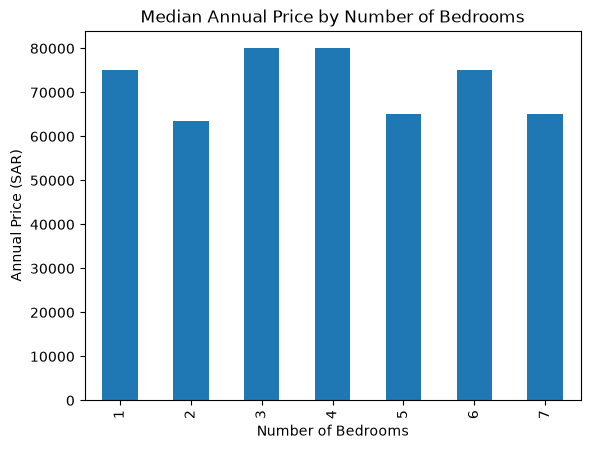

In [27]:
df_analysis.groupby("bedrooms")["annual_price"].median().plot(kind="bar",
    title="Median Annual Price by Number of Bedrooms",
    xlabel="Number of Bedrooms",
    ylabel="Annual Price (SAR)")
plt.savefig("slide8 BED.png", dpi=300, bbox_inches="tight")



plt.show()

**Objective 8 — Property age vs estimated annual price.** An age of zero may indicate a new property and is retained.

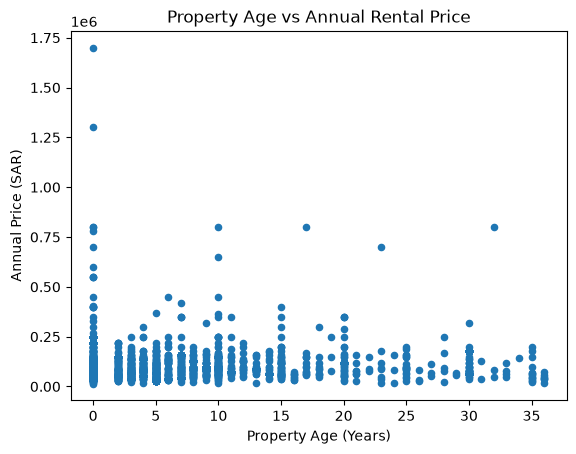

In [28]:
df_analysis.plot( kind="scatter",
    x="property_age",
    y="annual_price",
    title="Property Age vs Annual Rental Price",
    xlabel="Property Age (Years)",
    ylabel="Annual Price (SAR)")
plt.savefig("slide9_age.png.png", dpi=300, bbox_inches="tight")


plt.show()

In [29]:
df_analysis["property_age"].corr(df_analysis["annual_price"])

np.float64(0.1527354350077236)

**Objective 9 — Pool availability vs estimated annual price**

In [30]:
df_analysis.groupby("pool")["annual_price"].agg(
    ["count", "median"]
)

,count,median
pool,,
0,3112,70000.0
1,603,100000.0


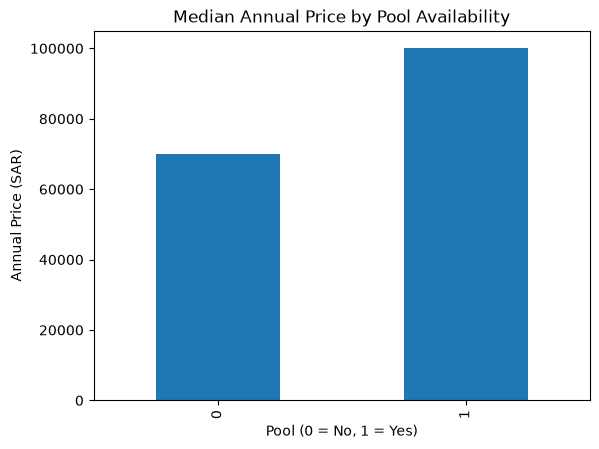

In [31]:
df_analysis.groupby("pool")["annual_price"].median().plot(
    kind="bar",
    title="Median Annual Price by Pool Availability",
    xlabel="Pool (0 = No, 1 = Yes)",
    ylabel="Annual Price (SAR)")
plt.savefig("slide10_pool.png.png", dpi=300, bbox_inches="tight")

plt.show()

**Objective 10 — Compare pool-related price differences within each city.**

In [32]:
df_analysis.groupby(["city", "pool"])["annual_price"].agg(
    ["count", "median"]
)

count    median
city   pool                 
الخبر  0       867   65000.0
       1       109   80000.0
الدمام 0       841   60000.0
       1        52   60000.0
الرياض 0       866   80000.0
       1        94  125000.0
جدة    0       538   80000.0
       1       348  140000.0

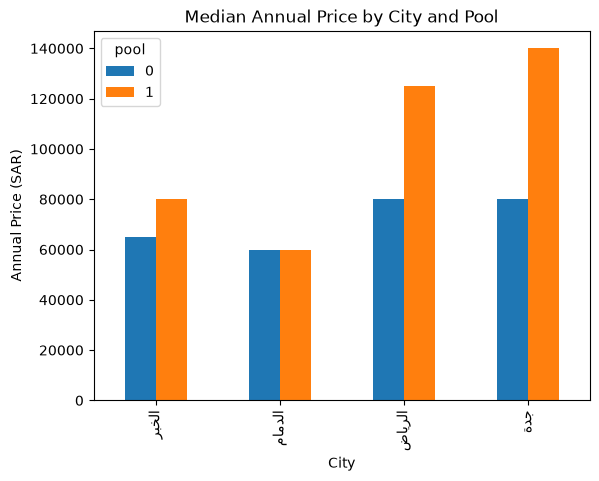

In [33]:
df_analysis.groupby(["city", "pool"])["annual_price"].median().unstack().plot(
    kind="bar",
    title="Median Annual Price by City and Pool",
    xlabel="City",
    ylabel="Annual Price (SAR)"
    )
plt.savefig("slide10_pool-1.png.png", dpi=300, bbox_inches="tight")


plt.show()

**Follow-up — Jeddah pool listings and size.** 

In [34]:
jeddah.groupby("pool")["size"].agg(
    ["count", "median"]
)

,count,median
pool,,
0,538,312.0
1,348,300.0


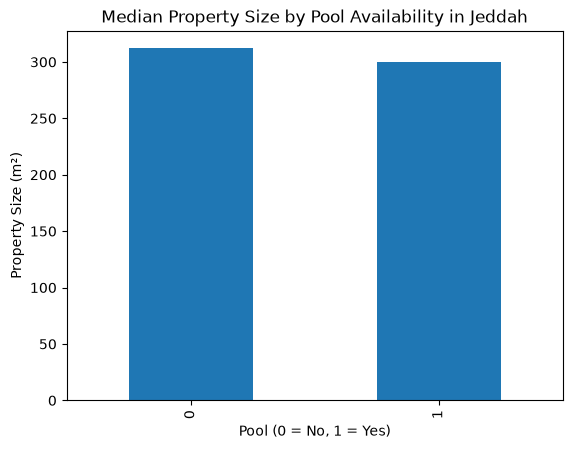

In [35]:
jeddah.groupby("pool")["size"].median().plot(
    kind="bar",
    title="Median Property Size by Pool Availability in Jeddah",
    xlabel="Pool (0 = No, 1 = Yes)",
    ylabel="Property Size (m²)"
)

plt.show()

In [36]:
jeddah_similar = jeddah[
    jeddah["size"].between(250, 400)
]

jeddah_similar.groupby("pool")["annual_price"].agg(
    ["count", "median"]
)

,count,median
pool,,
0,355,80000.0
1,261,150000.0


### Objective 11: Frontyard Availability and Rental Price

In [37]:

df_analysis["frontyard"].value_counts()


frontyard
1    2982
0     733
Name: count, dtype: int64

In [38]:

frontyard_price = df_analysis.groupby("frontyard")["annual_price"].agg(
    ["count", "median"]
)

frontyard_price


,count,median
frontyard,,
0,733,65000.0
1,2982,75000.0


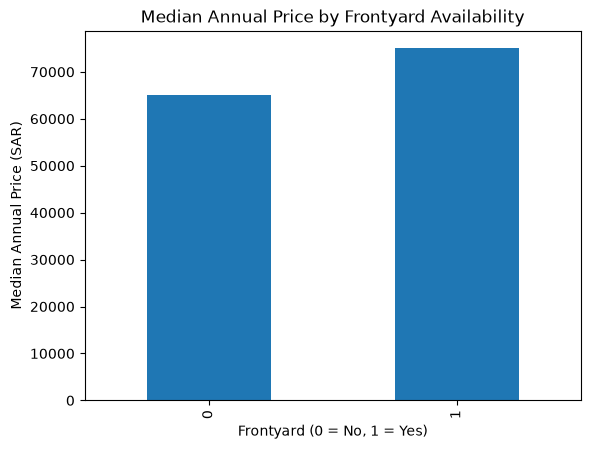

In [39]:

frontyard_price["median"].plot(
    kind="bar",
    title="Median Annual Price by Frontyard Availability",
    xlabel="Frontyard (0 = No, 1 = Yes)",
    ylabel="Median Annual Price (SAR)"
)
plt.savefig("slide11_frontyard.png", dpi=300, bbox_inches="tight")


plt.show()


In [40]:

df_analysis.groupby(["city", "frontyard"])["annual_price"].agg(
    ["count", "median"]
)


count    median
city   frontyard                 
الخبر  0            153   80000.0
       1            823   65000.0
الدمام 0            202   55000.0
       1            691   60000.0
الرياض 0            194   67500.0
       1            766   80000.0
جدة    0            184   65000.0
       1            702  100000.0

---

## Summary
__Summarizing the key insights from the analysis__

- There were 3,718 listing items in the original dataset; 3,715 items remained after filtering.
- The median estimated annual price was SAR 70,000. The median is used since extreme prices can influence the mean value.
- The maximum median estimated annual price and price per square meter could be observed in Jeddah – they were SAR 95,000 and about SAR 273/m² respectively.
- Property size was positively correlated to the price (r = 0.42), while property age was weakly correlated (r = 0.15).
- Prices did not show an increasing trend with an increase in the number of bedrooms.
- The median price of the properties equipped with swimming pools (SAR 100,000) was higher than that of those properties without pools (SAR 70,000).
- Pool-related price difference was not the same for all cities and was greatest in Jeddah.
-  The presence of frontyards influenced prices positively; however, this tendency was observed only for some cities.
    ...

## Recommendations/Conclusion
- Compare similar properties in the same city and district since location has been shown to affect the price.
- Compare property size and features instead of looking at the number of bedrooms or one feature only.
- Use the median when making comparisons between groups containing extremely priced properties.
- Check the rental periods before comparing the annual prices, which have been estimated on certain assumptions.
- Look out for duplicating properties through the use of property ID.
- Additional research will be needed to see if the differences in prices due to pools persist after controlling for the other variables.